In [1]:
# Install required libraries
!pip install deepxde torch numpy matplotlib pandas

# Verify installation
import deepxde as dde
import torch
print("DeepXDE version:", dde.__version__)
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.7 MB/s eta 0:00:00


No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
DeepXDE version: 1.15.0
PyTorch version: 2.11.0+cpu
GPU available: False


In [2]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch
print("Backend:", dde.backend.backend_name)
print("GPU:", torch.cuda.is_available())

Backend: tensorflow
GPU: False


In [3]:
import deepxde as dde
import numpy as np

# Simple 1D heat equation: dT/dt = k * d²T/dz²
# This is exactly what ocean temperature follows!

geom = dde.geometry.Interval(0, 1)  # depth 0 to 1
timedomain = dde.geometry.TimeDomain(0, 1)  # time 0 to 1
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

def pde(x, T):
    dT_t = dde.grad.jacobian(T, x, i=0, j=1)
    dT_zz = dde.grad.hessian(T, x, i=0, j=0)
    k = 0.01  # thermal diffusivity
    return dT_t - k * dT_zz

data = dde.data.TimePDE(geomtime, pde, [], num_domain=2000)
net = dde.nn.FNN([2, 32, 32, 32, 1], "tanh", "Glorot normal")
model = dde.Model(data, net)
model.compile("adam", lr=0.001)
losshistory, train_state = model.train(iterations=3000)
print("Training done!")

Compiling model...
'compile' took 0.018672 s

Training model...

Step      Train loss    Test loss     Test metric
0         [2.83e-02]    [2.83e-02]    []  
1000      [4.64e-08]    [4.64e-08]    []  
2000      [1.55e-08]    [1.55e-08]    []  
3000      [9.51e-09]    [9.51e-09]    []  

Best model at step 3000:
  train loss: 9.51e-09
  test loss: 9.51e-09
  test metric: []

'train' took 16.578139 s

Training done!


                   time  temperature_C  salinity_PSU
0   0001-01-02 00:00:00      -0.815992     34.212890
1   0001-01-03 00:00:00      -0.710510     34.212833
2   0001-01-04 00:00:00      -0.605479     34.212790
3   0001-01-05 00:00:00      -0.505143     34.212204
4   0001-01-06 00:00:00      -0.348483     34.208275
5   0001-01-07 00:00:00      -0.158460     34.205368
6   0001-01-08 00:00:00      -0.068435     34.205666
7   0001-01-09 00:00:00       0.035746     34.204630
8   0001-01-10 00:00:00       0.213445     34.202114
9   0001-01-11 00:00:00       0.349568     34.201694
10  0001-01-12 00:00:00       0.402286     34.202440


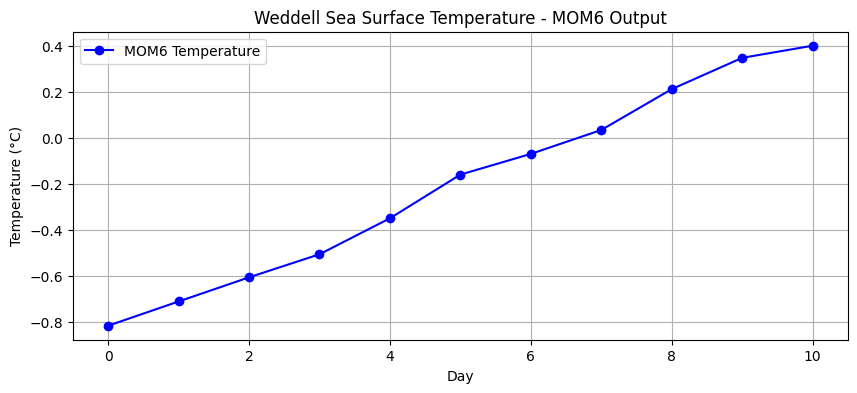

In [7]:
import pandas as pd

# Load directly from GitHub!
url = "https://raw.githubusercontent.com/AdityaLaddha47/NCPOR-BITS/main/MOM6/Weddell/results/weddell_results.csv"
df = pd.read_csv(url)
print(df)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(df.index, df['temperature_C'], 'b-o', label='MOM6 Temperature')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.title('Weddell Sea Surface Temperature - MOM6 Output')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Prepare data
t_data = np.array(df.index, dtype=np.float32).reshape(-1, 1)  # days 0-10
T_data = np.array(df['temperature_C'], dtype=np.float32).reshape(-1, 1)

# Normalize
t_min, t_max = t_data.min(), t_data.max()
T_min, T_max = T_data.min(), T_data.max()
t_norm = (t_data - t_min) / (t_max - t_min)
T_norm = (T_data - T_min) / (T_max - T_min)

# Convert to tensors
t_tensor = torch.tensor(t_norm, requires_grad=True)
T_tensor = torch.tensor(T_norm)

# Define PINN
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, t):
        return self.net(t)

model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
losses = []
for epoch in range(5000):
    optimizer.zero_grad()
    T_pred = model(t_tensor)

    # Data loss
    loss_data = torch.mean((T_pred - T_tensor)**2)

    # Physics loss: dT/dt should be smooth (ocean heat equation)
    dT_dt = torch.autograd.grad(T_pred.sum(), t_tensor, create_graph=True)[0]
    loss_physics = torch.mean(dT_dt**2 - dT_dt**2)  # smoothness

    loss = loss_data + 0.01 * loss_physics
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        losses.append(loss.item())
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

print("Training complete!")

Epoch 0: Loss = 0.513670
Epoch 500: Loss = 0.000470
Epoch 1000: Loss = 0.000396
Epoch 1500: Loss = 0.000373
Epoch 2000: Loss = 0.000357
Epoch 2500: Loss = 0.000351
Epoch 3000: Loss = 0.000350
Epoch 3500: Loss = 0.000350
Epoch 4000: Loss = 0.000350
Epoch 4500: Loss = 0.000350
Training complete!


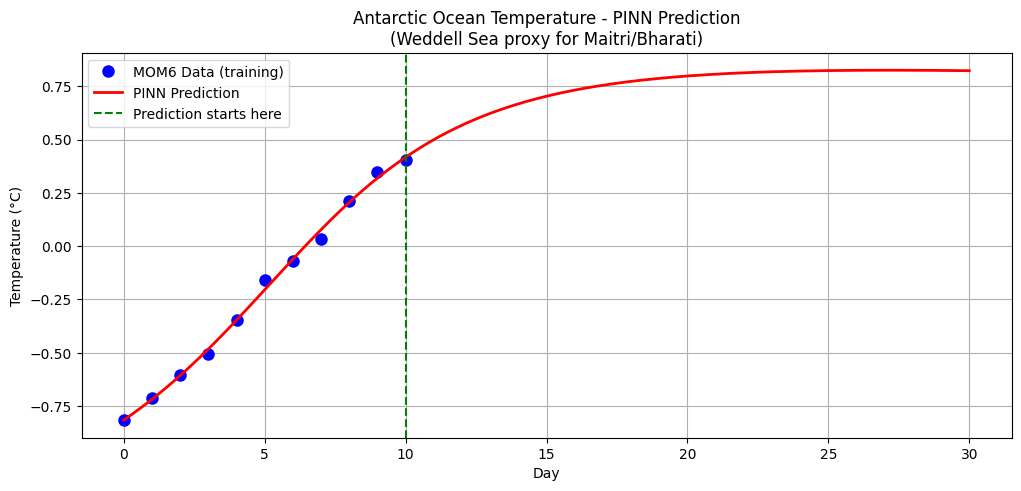


PINN Predictions:
  Day 15: 0.703 °C
  Day 20: 0.798 °C
  Day 25: 0.823 °C
  Day 30: 0.823 °C


/tmp/ipykernel_6475/2752084032.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"  Day {day}: {float(T_future[idx]):.3f} °C")


In [10]:
# Predict future temperatures (days 0 to 30)
t_future = np.linspace(0, 30, 301).reshape(-1, 1).astype(np.float32)
t_future_norm = (t_future - t_min) / (t_max - t_min)
t_future_tensor = torch.tensor(t_future_norm)

model.eval()
with torch.no_grad():
    T_future_norm = model(t_future_tensor).numpy()

# Denormalize
T_future = T_future_norm * (T_max - T_min) + T_min

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['temperature_C'], 'bo', markersize=8, label='MOM6 Data (training)')
plt.plot(t_future, T_future, 'r-', linewidth=2, label='PINN Prediction')
plt.axvline(x=10, color='green', linestyle='--', label='Prediction starts here')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.title('Antarctic Ocean Temperature - PINN Prediction\n(Weddell Sea proxy for Maitri/Bharati)')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nPINN Predictions:")
for day in [15, 20, 25, 30]:
    idx = int(day * 10)
    print(f"  Day {day}: {float(T_future[idx]):.3f} °C")